# TP4 :  Learning on a low budget
**Théo Rudkiewicz, Cyriaque Rousselot**

In [ ]:
%load_ext autoreload
%autoreload 2

# Introduction

**Context :**

Assume we are in a context where few "gold" labeled data samples are available for training, say

$$\mathcal{X}_{\text{train}} = \{(x_n,y_n)\}_{n\leq N_{\text{train}}}$$

where $N_{\text{train}}$ is small.

A large test set $\mathcal{X}_{\text{test}}$ exists but is not accessible.
(To make your task easier, we provide you with some data (named `test_dataset` in the code) that you can use to test your model, but you **must not** use it to train your model).

We also assume that we have a limited computational budget.

The goal of this practical session is to guide you through different methods that will help you get better results from few resources (data & compute).

In this practical, we will use the `resnet18` architecture. We will use models from the [pytorch vision hub ](https://pytorch.org/vision/stable/models.html#).

# QUESTIONS

## Grading

You will be graded on 5 questions. You will need to provide 7 files :
1. This Notebook
2. `utils.py`
3. `last_layer_finetune.pth` (the file **must be of size less than 5Mo**)
4. `daug_resnet.pth` (the file **must be of size less than 50Mo**)
5. `final_model.pth` (the file **must be of size less than 50Mo**)
6. `drawing_lora.png`
7. `cutmix.png`

If the code you defined passes all our tests, you will get the full grade. Otherwise we  will look at the intermediate questions in the notebook to give you partial credit.



 Please provide clear and short answers between `<div class="alert alert-info">  <your answer>  </div>` tags (when it's not code).  

<div class="alert alert-info">  Example of answer  </div>

In [ ]:
import os

if not os.path.exists("data"):
    os.mkdir("data")
if not os.path.exists("data/TP4_images"):
    os.mkdir("data/TP4_images")
    !cd data/TP4_images && wget -O north_dataset_train.zip  "https://nextcloud.lisn.upsaclay.fr/index.php/s/yzQRWE2YjmFn9WA/download/north_dataset_train.zip" && unzip north_dataset_train.zip
    !cd data/TP4_images && wget -O north_dataset_test.zip  "https://nextcloud.lisn.upsaclay.fr/index.php/s/zntidWrFdYsGMDm/download/north_dataset_test.zip" && unzip north_dataset_test.zip
dir_path = "data/TP4_images/"


In [3]:
import torch
import torch.nn as nn
from torchvision import datasets, transforms, models
from torchmetrics.classification import BinaryAccuracy, Accuracy, ConfusionMatrix
# you can install torchmetrics with `pip install torchmetrics`


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


north_dataset = datasets.ImageFolder(
    dir_path + "north_dataset_sample",
    transform=transforms.Compose([transforms.ToTensor()]),
)
test_dataset = datasets.ImageFolder(
    dir_path + "north_dataset_test",
    transform=transforms.Compose([transforms.ToTensor()]),
)
base_model = models.resnet18()

## Question 1 :
>  Change the last layer of the resnet model so that its size fits the problem.

In [4]:
base_model = models.resnet18(num_classes=2)

def change_lastlayer(num_classes):
    base_model.fc = nn.Linear(base_model.fc.in_features, num_classes)
    return base_model
base_model = change_lastlayer(2)

In [5]:
# Hint
print(base_model)
assert (
    base_model.fc.out_features == 2
)  # we could also change the last layer to have 1 output. Do it with 2 so that it matches our tests procedure during grading.



ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

## Question 2:
> Train the last layer of a randomly initialized resnet model. Provide a function precompute_features in `utils.py` that creates a new dataset from the features precomputed by the model.

Intermediate question :  Provide the training process in the notebook with training curve. Comment on the accuracy.

<div class="alert alert-info">  We pushed precompute_features in utils.py </div>

In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torch.optim import Adam
from torch.nn import CrossEntropyLoss
from torchmetrics.classification import BinaryAccuracy
from tqdm import tqdm
import matplotlib.pyplot as plt

def train_model(
    last_layer: nn.Module,
    precomputed_dataset: torch.utils.data.Dataset,
    precomputed_test_set: torch.utils.data.Dataset,
    device: torch.device,
    batch_size: int = 64,
    num_epochs: int = 10,
    learning_rate=1e-3,
    num_classes=2
) -> nn.Module:
    """
    Train the model on the precomputed dataset.

    Arguments:
    ----------
    last_layer: nn.Module
        The model to train (last layer).
    precomputed_dataset: torch.utils.data.Dataset
        The precomputed dataset for training.
    precomputed_test_set: torch.utils.data.Dataset
        The dataset for evaluation.
    device: torch.device
        The device to use for training.
    batch_size: int
        Batch size.
    num_epochs: int
        Number of epochs.
    learning_rate: float
        Learning rate.

    Returns:
    --------
    nn.Module
        Trained model.
    """

    losses = []
    test_losses = []
    train_accuracies = []
    test_accuracies = []

    last_layer = last_layer.to(device)
    last_layer.train()  # Set model to training mode

    train_dataloader = DataLoader(precomputed_dataset, batch_size=batch_size, shuffle=True)
    test_dataloader = DataLoader(precomputed_test_set, batch_size=batch_size, shuffle=False)

    optimizer = Adam(last_layer.parameters(), lr=learning_rate)
    criterion = CrossEntropyLoss()

    for epoch in range(num_epochs):
        last_layer.train()
        running_loss = 0.0
        train_accuracy_metric = BinaryAccuracy().to(device)  # Reset for each epoch
        train_accuracy_metric = Accuracy(num_classes=2, task="multiclass").to(device)

        for inputs, targets in tqdm(train_dataloader, desc=f"Epoch {epoch+1}/{num_epochs}"):
            inputs, targets = inputs.to(device), targets.to(device)

            optimizer.zero_grad()
            outputs = last_layer(inputs)
            loss = criterion(outputs, targets)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()

            preds = torch.argmax(outputs, dim=1)
            train_accuracy_metric.update(preds, targets)  # Update accuracy metric

        avg_loss = running_loss / len(train_dataloader)
        avg_train_acc = train_accuracy_metric.compute().item()  # Compute accuracy

        losses.append(avg_loss)
        train_accuracies.append(avg_train_acc)


        last_layer.eval()
        test_loss = 0
        test_accuracy_metric = BinaryAccuracy().to(device)  # Reset for evaluation
        test_accuracy_metric = Accuracy(num_classes=2, task="multiclass").to(device)

        with torch.no_grad():
            for inputs, targets in test_dataloader:
                inputs, targets = inputs.to(device), targets.to(device)

                outputs = last_layer(inputs)
                loss = criterion(outputs, targets)
                test_loss += loss.item()
                preds = torch.argmax(outputs, dim=1)

                test_accuracy_metric.update(preds, targets)

        test_accuracy = test_accuracy_metric.compute().item()  # Compute test accuracy
        test_loss /= len(test_dataloader)
        test_losses.append(test_loss)
        test_accuracies.append(test_accuracy)

    plt.figure()
    plt.plot(losses, label="Training Loss")
    plt.plot(test_losses, label="Test Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Loss during Training")
    plt.legend()
    plt.show()

    plt.figure()
    plt.plot(train_accuracies, label="Training Accuracy")
    plt.plot(test_accuracies, label="Test Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title("Accuracy during Training")
    plt.legend()
    plt.show()

    return last_layer


In [7]:
from utils import precompute_features, LastLayer
base_model=models.resnet18()
train_dataset_precomputed=precompute_features(
    base_model,
    north_dataset,
    device,
)
test_dataset_precomputed=precompute_features(
    base_model,
    test_dataset,
    device,
)
last_layer=LastLayer()

Epoch 100/100: 100%|██████████| 1/1 [00:00<00:00, 524.16it/s]


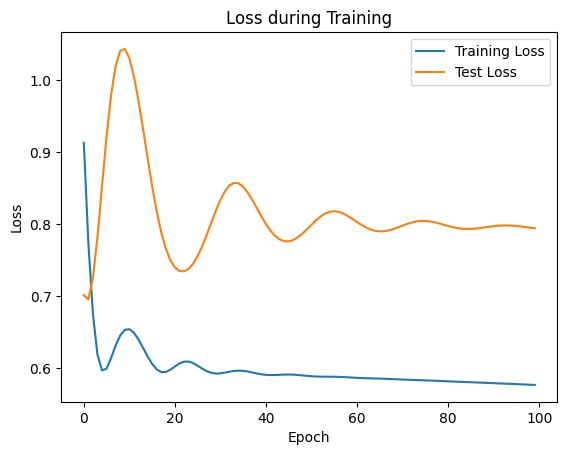

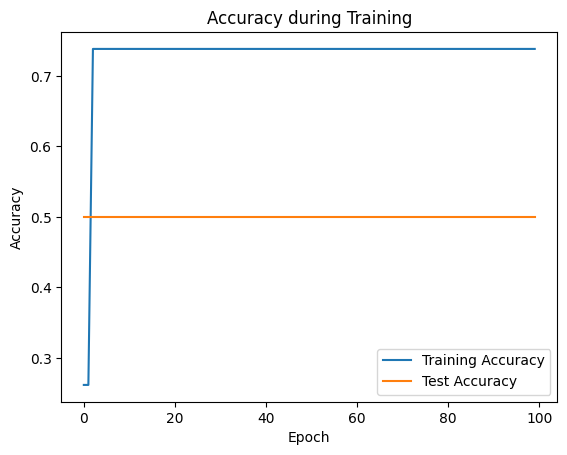

LastLayer(
  (fc): Linear(in_features=512, out_features=2, bias=True)
)

In [8]:
train_model(last_layer=last_layer,
            precomputed_dataset=train_dataset_precomputed,
            precomputed_test_set=test_dataset_precomputed,
            device=device,
            batch_size=64,
            num_epochs=100,
            learning_rate=0.001,
            )


<div class="alert alert-info">
The training accuracy is stable and converges quickly around 0.8. This stability could be explained that the random initialization gave stable  weights and the we train only a subpart of the network, leading to such stability.  However, the training accuracy does not increased with the number of epoch


The last layer alone does not possess enough expressive power to effectively capture complex patterns in the data, leading to no increase in the test accuracy or train accuracy . Additionally, the random initialization means that the extracted features may not be meaningful, further complicating learning.

As a result of this limitation, the test accuracy remains stagnant at a plateau (~0.5). This suggests that the model is unable to generalize well to unseen data, as the last layer does not have sufficient capacity to extract useful representations.
 </div>

## Question 3 :
> Now start from a pretained model on Imagenet (https://pytorch.org/vision/stable/models.html#) and only train the last layer. Provide the training process in the notebook with training curve.

 Provide two files : (https://pytorch.org/tutorials/beginner/saving_loading_models.html)
 -  a file  `utils.py` containing only the last layer class `LastLayer` inheriting from `torch.nn.Module` architecture of your final model to load
 -  a `last_layer_finetune.pth` file containing __only the last layer weights__ ( we will check the size)

 We will test your model on final accuracy on a test set.


In [9]:
from utils import LastLayer

base_model=models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
# the last layer will be removed in the precompute features !
Dataset=precompute_features(
    base_model,
    north_dataset,
    device,
)
test_dataset_precomputed=precompute_features(
    base_model,
    test_dataset,
    device,
)
base_model=change_lastlayer(2)
last_layer=LastLayer()

Epoch 100/100: 100%|██████████| 1/1 [00:00<00:00, 425.64it/s]


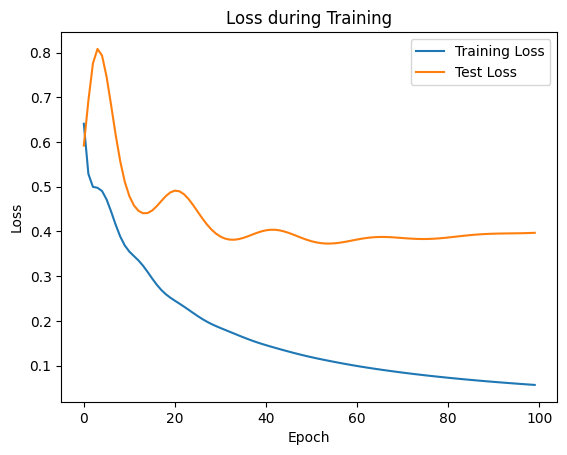

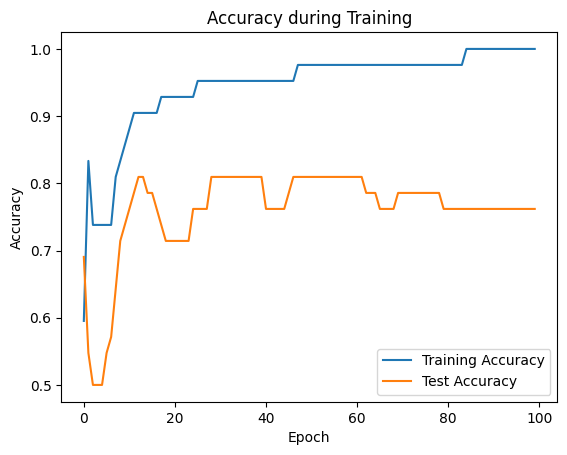

LastLayer(
  (fc): Linear(in_features=512, out_features=2, bias=True)
)

In [10]:
train_model(last_layer=last_layer,
            precomputed_dataset=Dataset,
            precomputed_test_set=test_dataset_precomputed,
            device=device,
            batch_size=64,
            num_epochs=100,
            learning_rate=0.001,
            )

In [11]:
torch.save(last_layer.state_dict(), "lastlayer_finetune.pth")

In [12]:
from utils import LastLayer


resnet = models.resnet18(weights="DEFAULT")
fc = LastLayer()  # !  Important : No argument
fc.load_state_dict(torch.load("lastlayer_finetune.pth", weights_only=True))
resnet.fc = fc
resnet.eval()
"model loaded"

/raid/home/bournez_pie/mva_geom/mva_geom_24/venv/lib/python3.8/site-packages/torch/_utils.py:831: UserWarning: TypedStorage is deprecated. It will be removed in the future and UntypedStorage will be the only storage class. This should only matter to you if you are using storages directly.  To access UntypedStorage directly, use tensor.untyped_storage() instead of tensor.storage()
  return self.fget.__get__(instance, owner)()


'model loaded'

<div class="alert alert-info">  Using the pretrained model provided interesting improvements in the test accuracy. After Convergence we have a test accuracy of 0.75, which peaked at 0.8</div>

## Question 4 :

> Perform  LoRA https://arxiv.org/pdf/2106.09685  on the model  (We are perfectly fine if you use an external library **for this question only**, and of course use it in the next questions). (Warning : without data augmentation it may not improve the accuracy.)

Intermediate question : Describe LoRA. There are different ways of implementing LoRa for convolutions. You can choose your preferred one. Explain the version of LoRa you used, provide a drawing of the process in the `drawing_lora.png` file. (Hint: you can obtain a small rank convolution by combining a convolution and a 1x1 convolution. One of the two goes from a higher number of channels to a lower number of channels and the other one restores the number of channels.)

__answer__:
<div class="alert alert-info">  
LoRA (Low-Rank Adaptation) is a technique introduced in the paper "LoRA: Low-Rank Adaptation of Large Language Models" (Hu et al., 2021). It aims to reduce the number of trainable parameters when fine-tuning large pre-trained models by injecting trainable low-rank matrices into their weight matrices instead of updating the full model parameters. This significantly reduces computational and memory costs.

LoRA is particularly effective for transformer-based architectures and can also be adapted for convolutional neural networks (CNNs). Instead of fine-tuning all layers, it introduces low-rank decomposition matrices into the weight updates. The key idea is that the weight updates can be represented in a lower-dimensional space, thereby reducing the number of parameters to optimize.

LoRA for Convolutions
For convolutional layers, LoRA can be implemented in different ways. The approach I used follows this scheme from [peft](https://github.com/huggingface/peft/blob/main/src/peft/tuners/lora/layer.py#L1013):

Decompose the original convolutional weight update into two smaller low-rank convolutions:
A 1×1 convolution that reduces the number of channels (lower-rank representation).
Another 1×1 convolution restores the original number of channels. The oevrall expression is given in the convNd_ class of the lora layers file provided above `result = result + lora_B(lora_A(dropout(x))) * scaling`, we ignored the scaling in the image. The `result` in the reght size of the equation commes from the base layer on which we are pluggin LoRA onto.
This method effectively approximates the original convolution using a lower-rank factorization while keeping expressivity.

![LoRA Process](drawing_lora.png)
  </div>

In [ ]:
# !pip install transformers peft bitsandbytes


In [25]:
from peft import LoraConfig, get_peft_model

resnet18 = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
resnet18 = change_lastlayer(2)
lora_config = LoraConfig(
    r=8,
    lora_alpha=32,
    lora_dropout=0.1,
    target_modules=["layer3.0.conv1", "layer3.0.conv2", "layer4.0.conv1", "layer4.0.conv2"],
)

# Frozen parameters of the base model
for param in resnet.parameters():
    param.requires_grad = False

lora_model = get_peft_model(resnet18, lora_config)


In [26]:
train_dataset=north_dataset
test_dataset_precomputed=test_dataset

Epoch 100/100: 100%|██████████| 1/1 [00:00<00:00, 11.57it/s]


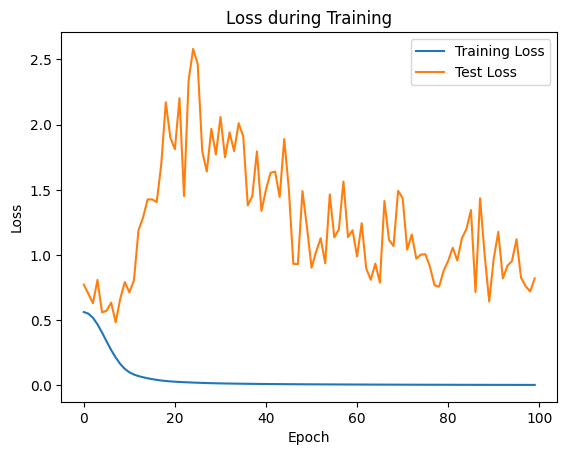

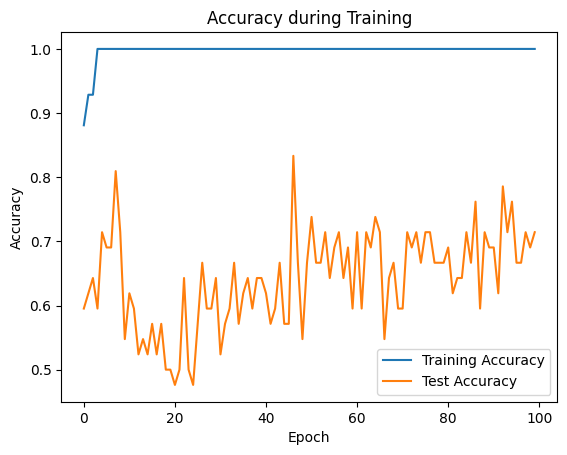

model trained!


In [27]:
lora_model.train()

train_model(
    last_layer=lora_model,
    precomputed_dataset=train_dataset,
    precomputed_test_set=test_dataset_precomputed,
    device=device,
    batch_size=64,
    num_epochs = 100,
    learning_rate = 0.001,
)
print("model trained!")

In [28]:
lora_model = lora_model.merge_and_unload()
torch.save(lora_model.state_dict(), "lora_resnet.pth")

<div class="alert alert-info"> As expected at the beginning of the question ,the model has an average test accuracy of 0.70 which is similar from the previous question. 
One explanation is that LORA was designed to large language models with millions of parameters with limited VRAM. here Resnet is rather shallow and the trainable models may not be expressive enough to provide better results.</div>

## Question 5 :
In order to better train our LORA weights, let's do some Data Augmentation https://en.wikipedia.org/wiki/Data_augmentation . Load some alteration of the data from the `torchvision.transforms` module and incorporate them in your training pipeline.

 Intermediate question : Check CutMix  (https://pytorch.org/vision/stable/auto_examples/transforms/plot_cutmix_mixup.html#sphx-glr-auto-examples-transforms-plot-cutmix-mixup-py) and explain it with a small drawing `cutmix.png`.


  Provide one file : (https://pytorch.org/tutorials/beginner/saving_loading_models.html)
 -  a `daug_resnet.pth` file containing the weight of the ResNet18 after DAUG  (  !  It  has to be of the class ResNet so you have to merge LoRA weights with the ResNet18 weights)

In [29]:
import torch
import torchvision.transforms as transforms
from torchvision.transforms.v2 import functional as F
import random
import numpy as np

# Define CutMix augmentation
class CutMix:
    def __init__(self, alpha=1.0, prob=0.5):
        self.alpha = alpha
        self.prob = prob

    def __call__(self, img, target, img2, target2):
        if random.random() > self.prob:
            return img, target

        # Sample lambda from beta distribution
        lam = np.random.beta(self.alpha, self.alpha)
        # Generate random bounding box
        W, H = img.size
        cut_w = int(W * np.sqrt(1 - lam))
        cut_h = int(H * np.sqrt(1 - lam))
        cx, cy = np.random.randint(W), np.random.randint(H)

        x1 = max(cx - cut_w // 2, 0)
        y1 = max(cy - cut_h // 2, 0)
        x2 = min(cx + cut_w // 2, W)
        y2 = min(cy + cut_h // 2, H)


        img.paste(img2.crop((x1, y1, x2, y2)), (x1, y1, x2, y2))

        # Adjusting labels with linear relationship
        lam = 1 - ((x2 - x1) * (y2 - y1) / (W * H))
        new_target = target if lam > 0.5 else target2

        return img, new_target

transforms = transforms.Compose([
    transforms.ToTensor(),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

class CutMixDataset:
    def __init__(self, dataset, alpha=1.0, prob=0.5):
        self.dataset = dataset
        self.cutmix = CutMix(alpha=alpha, prob=prob)

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, index):
        # Fetch two random samples and apply cutmix and the usual transforms
        img1, target1 = self.dataset[index]
        img2, target2 = self.dataset[random.randint(0, len(self.dataset) - 1)]
        img1, target1 = self.cutmix(img1, target1, img2, target2)
        img1 = transforms(img1)
        return img1, target1



<div class="alert alert-info">  We create here cutmix.png  </div>

In [33]:
class CutMixDisplay:
    def __init__(self, alpha=1.0, prob=0.5):
        self.alpha = alpha
        self.prob = prob

    def __call__(self, img, target, img2, target2):
        if random.random() > self.prob:
            return img, target

        # Sample lambda from beta distribution
        lam = np.random.beta(self.alpha, self.alpha)
        # Generate random bounding box
        W, H = img.size
        cut_w = int(W * np.sqrt(1 - lam))
        cut_h = int(H * np.sqrt(1 - lam))
        cx, cy = np.random.randint(W), np.random.randint(H)
        self.cut_w = cut_w
        self.cut_h = cut_h
        self.cx = cx
        self.cy = cy

        x1 = max(cx - cut_w // 2, 0)
        y1 = max(cy - cut_h // 2, 0)
        x2 = min(cx + cut_w // 2, W)
        y2 = min(cy + cut_h // 2, H)


        img.paste(img2.crop((x1, y1, x2, y2)), (x1, y1, x2, y2))

        # Adjusting labels with linear relationship
        lam = 1 - ((x2 - x1) * (y2 - y1) / (W * H))
        new_target = target if lam > 0.5 else target2

        return img, new_target

In [34]:
train_dataset = datasets.ImageFolder(
    dir_path + "north_dataset_sample",
    transform=None,
)
test_dataset = datasets.ImageFolder(
    dir_path + "north_dataset_test",
    transform=None,
)
ApplyCutMix = CutMixDisplay(alpha=1.0, prob=1)

# train_dataset = CutMixDataset(train_dataset, alpha=1.0, prob=0.5)
# test_dataset = CutMixDataset(test_dataset, alpha=1.0, prob=0.5)
img1, target1 = train_dataset[0]
img1_inp=img1.copy()
img2, target2 = train_dataset[1]
res= ApplyCutMix(img1,target1,img2,target2)[0]


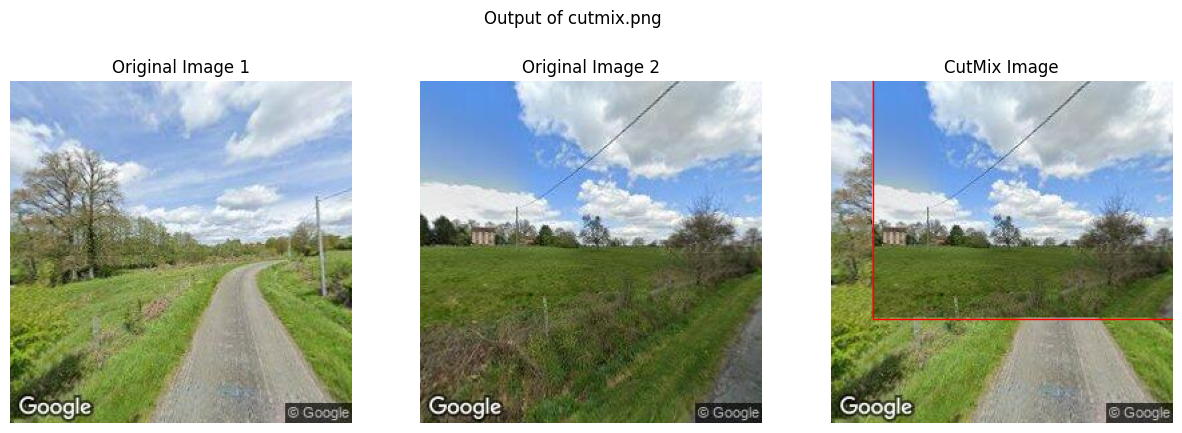

In [35]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Display Original Image 1
axes[0].imshow(img1_inp)
axes[0].axis('off')
axes[0].set_title("Original Image 1")

# Display Original Image 2
axes[1].imshow(img2)
axes[1].axis('off')
axes[1].set_title("Original Image 2")

# Display CutMix Image
axes[2].imshow(res)
axes[2].axis('off')
axes[2].set_title("CutMix Image")

# Add a rectangle to indicate CutMix region
rect = plt.Rectangle((ApplyCutMix.cx - ApplyCutMix.cut_w // 2, ApplyCutMix.cy - ApplyCutMix.cut_h // 2),
                     ApplyCutMix.cut_w, ApplyCutMix.cut_h, linewidth=1, edgecolor='r', facecolor='none')
axes[2].add_patch(rect)

plt.suptitle("Output of cutmix.png")

plt.savefig("cutmix.png")
plt.show()


<div class="alert alert-info">  CutMix is a data augmentation technique that enhances model generalization by combining two images and their labels. It involves cutting a rectangular region from one image and pasting it onto another, with the label being a proportional mix based on the patch size. This encourages the model to learn from multiple regions of images, improving robustness and reducing overfitting. In the image above, what we see is that a part of the countryside of image 2 is put onto the image 1. The model needs to look at the entirety of the image as the bounding box pasted on the image 1 is chosen randomly. This is to avoid the model to learn the class on artifacts, like the sky for instance. </div>

Epoch 100/100: 100%|██████████| 1/1 [00:00<00:00,  2.07it/s]


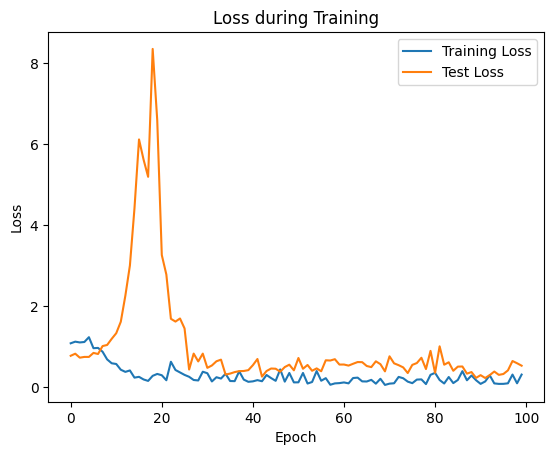

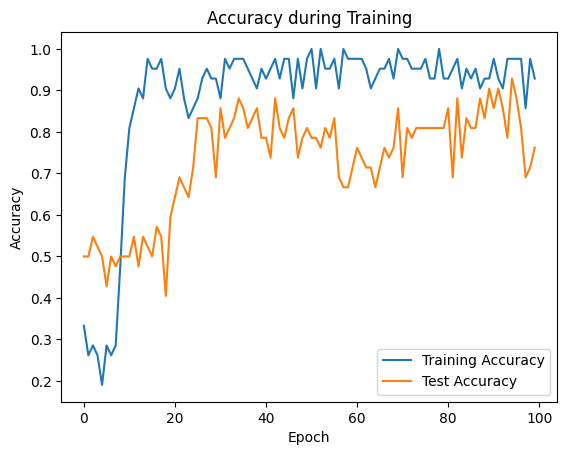

model trained!


In [36]:
train_dataset = datasets.ImageFolder(
    dir_path + "north_dataset_sample",
    transform=None,
)
test_dataset = datasets.ImageFolder(
    dir_path + "north_dataset_test",
    transform=None,
)
train_dataset = CutMixDataset(train_dataset, alpha=1.0, prob=0.5)
test_dataset = CutMixDataset(test_dataset, alpha=1.0, prob=0.5)

resnet = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
fc = LastLayer()  # !  Important : No argument
# fc.load_state_dict(torch.load("last_layer_finetune.pth", weights_only=True))
# fc.load_state_dict(torch.load("/content/lastlayer_finetune.pth", weights_only=True))
resnet.fc = fc
resnet.train()

lora_config = LoraConfig(
    r=8,
    lora_alpha=32,
    lora_dropout=0.1,
    target_modules=["layer3.0.conv1", "layer3.0.conv2", "layer4.0.conv1", "layer4.0.conv2"],
)
# Apply LoRA to the model
lora_model = get_peft_model(resnet, lora_config)

# Train the LoRA model using augmented dataset
train_model(
    last_layer=lora_model,
    precomputed_dataset=train_dataset,
    precomputed_test_set=test_dataset,
    device=device,
    batch_size=64,
    num_epochs=100,
    learning_rate=0.001,
)
print("model trained!")

In [37]:
lora_model=lora_model.merge_and_unload()
# Ensure the final model is of type `torchvision.models.ResNet`
assert isinstance(lora_model, models.ResNet), "The final model is not a torchvision.models.ResNet instance!"

# Save the final model with merged LoRA weights
torch.save(lora_model.state_dict(), "daug_resnet.pth")
assert isinstance(lora_model, models.ResNet)
print("Successfully converted LoRA model back to ResNet18 and saved as 'daug_resnet.pth'.")


Successfully converted LoRA model back to ResNet18 and saved as 'daug_resnet.pth'.


<div class="alert alert-info">   The test accuracy when trained with a LoRA pretained models is now 0.9. CutMix increased the overall noise on the accuracy in the sampling and improved the overall results. This is probably due to our implementation where we need to define an int class label and thus an if else condition is necessary in the cutmix dataset (the label of the modified image is defined by the size of the box compared to the original image), this leads to the model struggling to learn the class based on small patterns. This is desired as we want to find the best result overall. </div>

## Question 6 : (BONUS)
> Do the best you can : improve performance on test set while keeping ResNet 18 architecture, or decrease the size of the model

Provide a file  `final_model.pth` containing the weights of the final model and provide the class `FinalModel()` in the `utils.py` file.

Epoch [1/100], Train Loss: -0.3607, Train Acc: 0.2857, Test Loss: -0.1684, Test Acc: 0.5714
Epoch [2/100], Train Loss: -0.3543, Train Acc: 0.3095, Test Loss: -0.0931, Test Acc: 0.4524
Epoch [3/100], Train Loss: -0.3579, Train Acc: 0.2857, Test Loss: -0.1638, Test Acc: 0.5714
Epoch [4/100], Train Loss: -0.3710, Train Acc: 0.4286, Test Loss: -0.1275, Test Acc: 0.4762
Epoch [5/100], Train Loss: -0.3715, Train Acc: 0.3571, Test Loss: -0.1648, Test Acc: 0.5000
Epoch [6/100], Train Loss: -0.3862, Train Acc: 0.3095, Test Loss: -0.1452, Test Acc: 0.4762
Epoch [7/100], Train Loss: -0.4078, Train Acc: 0.3810, Test Loss: -0.1526, Test Acc: 0.5000
Epoch [8/100], Train Loss: -0.4291, Train Acc: 0.5238, Test Loss: -0.1603, Test Acc: 0.5000
Epoch [9/100], Train Loss: -0.4405, Train Acc: 0.5714, Test Loss: -0.1246, Test Acc: 0.4762
Epoch [10/100], Train Loss: -0.4351, Train Acc: 0.6905, Test Loss: -0.1394, Test Acc: 0.5476
Epoch [11/100], Train Loss: -0.4610, Train Acc: 0.7381, Test Loss: -0.1855, Tes

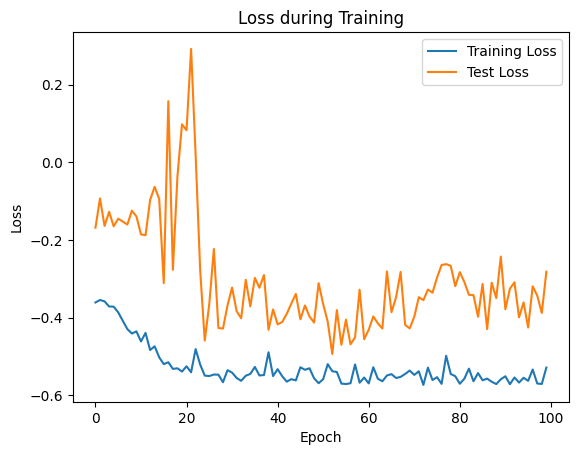

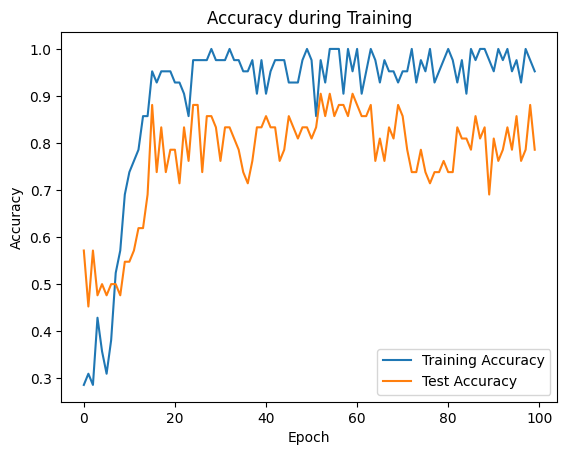

In [ ]:
import matplotlib.pyplot as plt
from torchmetrics.classification import Accuracy

# Teacher and Student Models
teacher_model = models.resnet101(pretrained=True).to(device)
resnet = models.resnet18(weights="DEFAULT").to(device)
fc = LastLayer()  # !  Important : No argument
# fc.load_state_dict(torch.load("last_layer_finetune.pth", weights_only=True))
# fc.load_state_dict(torch.load("/content/lastlayer_finetune.pth", weights_only=True))
resnet.fc = fc.to(device)
resnet.train()

lora_config = LoraConfig(
    r=8,
    lora_alpha=32,
    lora_dropout=0.1,
    target_modules=["layer3.0.conv1", "layer3.0.conv2", "layer4.0.conv1", "layer4.0.conv2"],
)
# Apply LoRA to the model
resnet = get_peft_model(resnet, lora_config)

teacher_model.fc = nn.Linear(teacher_model.fc.in_features, 2).to(device)

for param in teacher_model.parameters():
    param.requires_grad = False




def train_kd(
    teacher, student, train_dataset, test_dataset, device,
    batch_size=64, num_epochs=100, learning_rate=1e-3, alpha=0.5, temperature=3
):
    """
    Train the student model with knowledge distillation while plotting loss and accuracy.

    Args:
        teacher: Teacher model (pre-trained and frozen).
        student: Student model to be trained.
        train_dataset: Dataset for training.
        test_dataset: Dataset for testing.
        device: Device to use ('cuda' or 'cpu').
        batch_size: Batch size for DataLoader.
        num_epochs: Number of epochs to train.
        learning_rate: Learning rate for the optimizer.
        alpha: Weight for balancing CE and KD losses.
        temperature: Temperature for knowledge distillation.
    """

    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

    criterion_ce = nn.CrossEntropyLoss()
    criterion_kd = nn.KLDivLoss(reduction="batchmean")
    train_acc_metric = Accuracy(num_classes=2, task="multiclass").to(device)
    test_acc_metric = Accuracy(num_classes=2, task="multiclass").to(device)


    optimizer = torch.optim.Adam(student.parameters(), lr=learning_rate)

    # Initialize metrics tracking
    train_losses, test_losses = [], []
    train_accuracies, test_accuracies = [], []

    # Training loop
    for epoch in range(num_epochs):
        student.train()
        teacher.eval()
        running_loss = 0.0
        train_acc_metric.reset()

        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)


            student_logits = student(inputs)
            with torch.no_grad():
                teacher_logits = teacher(inputs)

            # Losses We have both CE on the two models (for the teacher we only train the last layer)
            # We also use a KL divergence on the two output ditributions so we make sure the student model
            # is never too far from the teacher
            loss_ce = criterion_ce(student_logits, labels)
            loss_teacher = criterion_ce(teacher_logits, labels)
            loss_kd = criterion_kd(
                nn.functional.softmax(student_logits / temperature, dim=1),
                nn.functional.softmax(teacher_logits / temperature, dim=1)
            )
            loss = alpha / 2 * loss_ce + (1 - alpha) * loss_kd

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()


            running_loss += loss.item()
            preds = student_logits.argmax(dim=1)
            train_acc_metric.update(preds, labels)

        avg_loss = running_loss / len(train_loader)
        avg_accuracy = train_acc_metric.compute().item()

        train_losses.append(avg_loss)
        train_accuracies.append(avg_accuracy)

        # Evaluation phase
        student.eval()
        test_loss = 0.0
        test_acc_metric.reset()
        with torch.no_grad():
            for inputs, labels in test_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                student_logits = student(inputs)
                teacher_logits = teacher(inputs)

                loss_ce = criterion_ce(student_logits, labels)
                loss_kd = criterion_kd(
                    nn.functional.softmax(student_logits / temperature, dim=1),
                    nn.functional.softmax(teacher_logits / temperature, dim=1)
                )
                loss = alpha * loss_ce + (1 - alpha) * loss_kd
                test_loss += loss.item()

                preds = student_logits.argmax(dim=1)
                test_acc_metric.update(preds, labels)

        avg_test_loss = test_loss / len(test_loader)
        avg_test_accuracy = test_acc_metric.compute().item()

        test_losses.append(avg_test_loss)
        test_accuracies.append(avg_test_accuracy)

        print(f"Epoch [{epoch+1}/{num_epochs}], Train Loss: {avg_loss:.4f}, "
              f"Train Acc: {avg_accuracy:.4f}, Test Loss: {avg_test_loss:.4f}, Test Acc: {avg_test_accuracy:.4f}")

    # Plotting results
    plt.figure()
    plt.plot(train_losses, label="Training Loss")
    plt.plot(test_losses, label="Test Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Loss during Training")
    plt.legend()
    plt.show()

    plt.figure()
    plt.plot(train_accuracies, label="Training Accuracy")
    plt.plot(test_accuracies, label="Test Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title("Accuracy during Training")
    plt.legend()
    plt.show()

    return student

resnet = train_kd(
    teacher_model, resnet, train_dataset, test_dataset,
    device=device,
)

In [ ]:
torch.save(resnet.state_dict(), "final_model.pth")

<div class="alert alert-info"> This setup uses knowledge distillation, where a smaller student model learns from a larger teacher model. The teacher model is a pre-trained ResNet-101, modified to allow fine-tuning of its last fully connected layer while keeping the rest of its parameters frozen. The student model is a ResNet-18 enhanced with LoRA, which enables efficient fine-tuning by adding low-rank learnable parameters to specific layers. During training, the student learns by combining cross-entropy loss, which focuses on predicting the correct class labels, and knowledge distillation loss, which encourages it to mimic the teacher's softened predictions. This approach fine-tunes the teacher's last layer for better alignment with the dataset while training the student to replicate the teacher's performance, enabling effective and efficient knowledge transfer.</div>